# Normalverteilung und Regression #

## Datentransformation ##

In [1]:
import pandas as pd
import numpy as np

# Datensatz einlesen
df = pd.read_excel("listings_adjusted_iqr_bereinigt_kodiert.xlsx")

# Name deiner Zielvariable
zielvariable = "review_scores_rating"

# reflektierte Log-Transformation
df[zielvariable + "_log_reflected"] = np.log(
    df[zielvariable].max() + 1 - df[zielvariable]
)

# Kontrolle
print(df[[zielvariable, zielvariable + "_log_reflected"]].head())

   review_scores_rating  review_scores_rating_log_reflected
0                  4.63                            0.314811
1                  5.00                            0.000000
2                  4.68                            0.277632
3                  4.77                            0.207014
4                  4.48                            0.418710


C:\Users\Sani\AppData\Local\Temp\ipykernel_20072\1690701896.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[zielvariable + "_log_reflected"] = np.log(


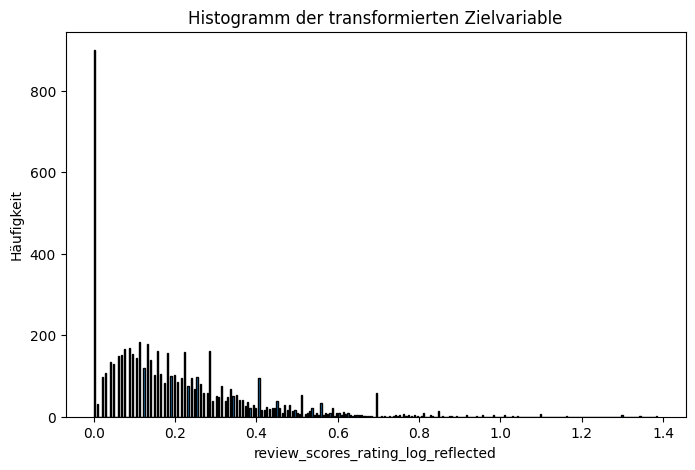

In [3]:
import matplotlib.pyplot as plt

spalte = "review_scores_rating_log_reflected"

plt.figure(figsize=(8, 5))
plt.hist(df[spalte].dropna(), bins=500, edgecolor="black")
plt.xlabel(spalte)
plt.ylabel("Häufigkeit")
plt.title("Histogramm der transformierten Zielvariable")
plt.show()

führt nicht zur Normalverteilung

In [14]:
import pandas as pd
import statsmodels.api as sm

df = pd.read_excel("listings_adjusted_iqr_bereinigt.xlsx")

zielvariable = "review_scores_rating"

praediktoren = ['review_scores_accuracy',
'review_scores_cleanliness',
'review_scores_checkin',
'review_scores_communication',
'review_scores_location',
'review_scores_value'
]

daten_regression = df[[zielvariable] + praediktoren]

y = daten_regression[zielvariable]
X = daten_regression[praediktoren]

X = sm.add_constant(X)

modell1 = sm.OLS(y, X).fit()

print(modell1.summary())

                             OLS Regression Results                             
Dep. Variable:     review_scores_rating   R-squared:                       0.879
Model:                              OLS   Adj. R-squared:                  0.879
Method:                   Least Squares   F-statistic:                     7599.
Date:                  Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                          12:22:37   Log-Likelihood:                 6041.7
No. Observations:                  6298   AIC:                        -1.207e+04
Df Residuals:                      6291   BIC:                        -1.202e+04
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------

In [15]:
import pandas as pd
import statsmodels.api as sm

df = pd.read_excel("listings_adjusted_iqr_bereinigt.xlsx")

zielvariable = "review_scores_rating"

praediktoren = ['accommodates',
'price',
'minimum_nights',
'availability_365',
'calculated_host_listings_count',
'is_superhost',
'is_instant_bookable'
]



daten_regression = df[[zielvariable] + praediktoren]

# inf und -inf in NaN umwandeln
daten_regression = daten_regression.replace([np.inf, -np.inf], np.nan)

# Zeilen mit NaN entfernen
daten_regression = daten_regression.dropna()

y = daten_regression[zielvariable]
X = daten_regression[praediktoren]

X = sm.add_constant(X)

modell2 = sm.OLS(y, X).fit()

print(modell2.summary())

                             OLS Regression Results                             
Dep. Variable:     review_scores_rating   R-squared:                       0.225
Model:                              OLS   Adj. R-squared:                  0.225
Method:                   Least Squares   F-statistic:                     256.8
Date:                  Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                          12:22:46   Log-Likelihood:                 189.75
No. Observations:                  6184   AIC:                            -363.5
Df Residuals:                      6176   BIC:                            -309.7
Df Model:                             7                                         
Covariance Type:              nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

Residuen berechnen

In [16]:
residuen_1 = modell1.resid
residuen_2 = modell2.resid

vorhergesagte_werte_1 = modell1.fittedvalues
vorhergesagte_werte_2 = modell2.fittedvalues

Histogramm der Residuen

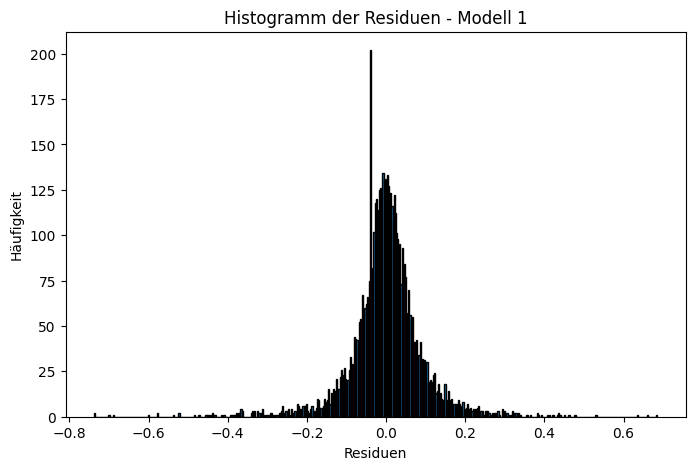

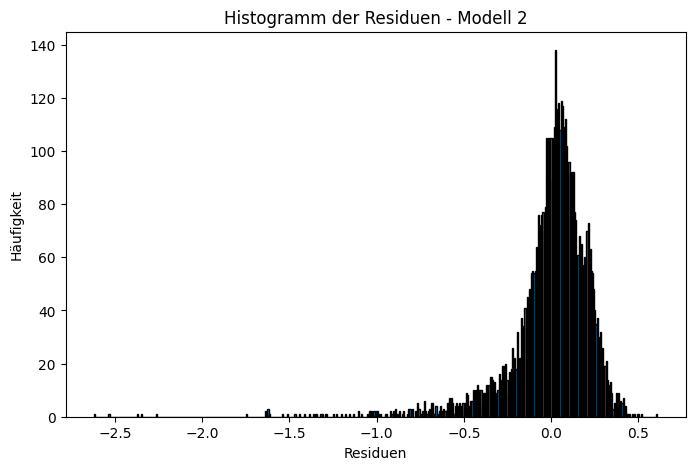

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(residuen_1, bins=500, edgecolor="black")
plt.xlabel("Residuen")
plt.ylabel("Häufigkeit")
plt.title("Histogramm der Residuen - Modell 1")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(residuen_2, bins=500, edgecolor="black")
plt.xlabel("Residuen")
plt.ylabel("Häufigkeit")
plt.title("Histogramm der Residuen - Modell 2")
plt.show()

In [18]:
from scipy.stats import shapiro

stat_1, p_1 = shapiro(residuen_1)
stat_2, p_2 = shapiro(residuen_2)

print("Shapiro-Wilk-Test Modell 1")
print("Statistik:", round(stat_1, 4))
print("p-Wert:", round(p_1, 5))

print()

print("Shapiro-Wilk-Test Modell 2")
print("Statistik:", round(stat_2, 4))
print("p-Wert:", round(p_2, 5))

Shapiro-Wilk-Test Modell 1
Statistik: 0.8974
p-Wert: 0.0

Shapiro-Wilk-Test Modell 2
Statistik: 0.8166
p-Wert: 0.0


c:\Users\Sani\OneDrive\Dokumente\BACHELOR INFORMATIK\Projekt\Airbnb\data-science-project-airbnb\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6298.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\Sani\OneDrive\Dokumente\BACHELOR INFORMATIK\Projekt\Airbnb\data-science-project-airbnb\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6184.
  res = hypotest_fun_out(*samples, **kwds)


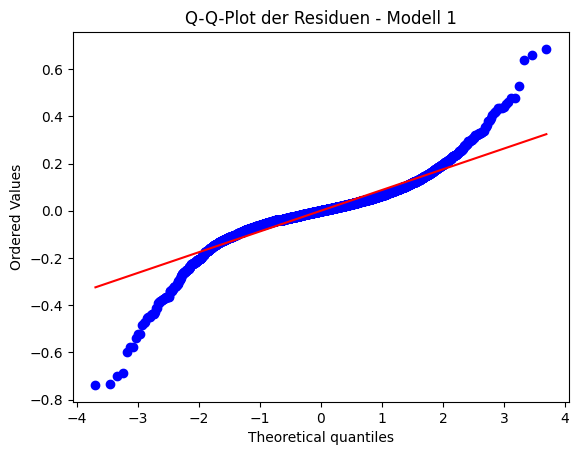

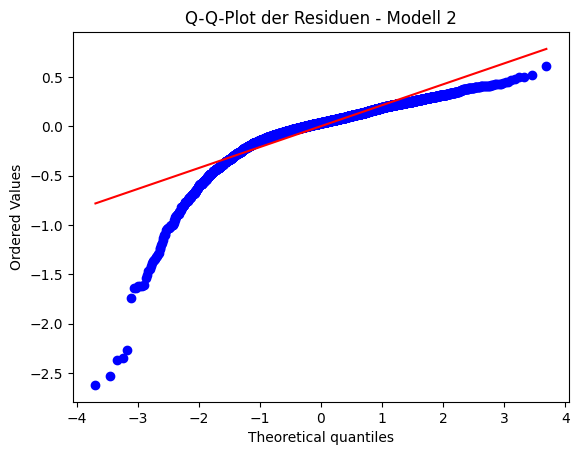

In [19]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(residuen_1, dist="norm", plot=plt)
plt.title("Q-Q-Plot der Residuen - Modell 1")
plt.show()

stats.probplot(residuen_2, dist="norm", plot=plt)
plt.title("Q-Q-Plot der Residuen - Modell 2")
plt.show()

# Regressionen für 4,31-4.99 #

In [22]:
import pandas as pd
import statsmodels.api as sm

df = pd.read_excel("listings_review_scores_4_31_bis_4_99.xlsx")

zielvariable = "review_scores_rating"

praediktoren = ['review_scores_accuracy',
'review_scores_cleanliness',
'review_scores_checkin',
'review_scores_communication',
'review_scores_location',
'review_scores_value'
]

daten_regression = df[[zielvariable] + praediktoren]

y = daten_regression[zielvariable]
X = daten_regression[praediktoren]

X = sm.add_constant(X)

modell3 = sm.OLS(y, X).fit()

print(modell3.summary())

                             OLS Regression Results                             
Dep. Variable:     review_scores_rating   R-squared:                       0.779
Model:                              OLS   Adj. R-squared:                  0.779
Method:                   Least Squares   F-statistic:                     2954.
Date:                  Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                          12:29:16   Log-Likelihood:                 5854.9
No. Observations:                  5029   AIC:                        -1.170e+04
Df Residuals:                      5022   BIC:                        -1.165e+04
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------

In [23]:

df = pd.read_excel("listings_adjusted_iqr_bereinigt.xlsx")

zielvariable = "review_scores_rating"

praediktoren = ['accommodates',
'price',
'minimum_nights',
'availability_365',
'calculated_host_listings_count',
'is_superhost',
'is_instant_bookable'
]



daten_regression = df[[zielvariable] + praediktoren]

# inf und -inf in NaN umwandeln
daten_regression = daten_regression.replace([np.inf, -np.inf], np.nan)

# Zeilen mit NaN entfernen
daten_regression = daten_regression.dropna()

y = daten_regression[zielvariable]
X = daten_regression[praediktoren]

X = sm.add_constant(X)

modell4 = sm.OLS(y, X).fit()

print(modell4.summary())

                             OLS Regression Results                             
Dep. Variable:     review_scores_rating   R-squared:                       0.225
Model:                              OLS   Adj. R-squared:                  0.225
Method:                   Least Squares   F-statistic:                     256.8
Date:                  Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                          12:29:33   Log-Likelihood:                 189.75
No. Observations:                  6184   AIC:                            -363.5
Df Residuals:                      6176   BIC:                            -309.7
Df Model:                             7                                         
Covariance Type:              nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

In [24]:
residuen_3 = modell3.resid
residuen_4 = modell4.resid

vorhergesagte_werte_3 = modell3.fittedvalues
vorhergesagte_werte_4 = modell4.fittedvalues

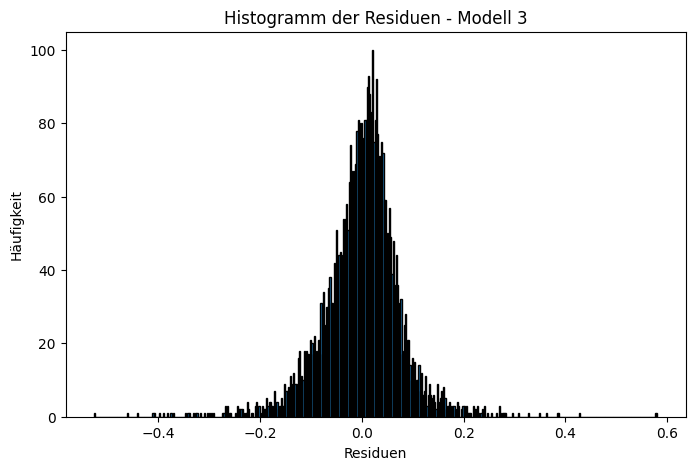

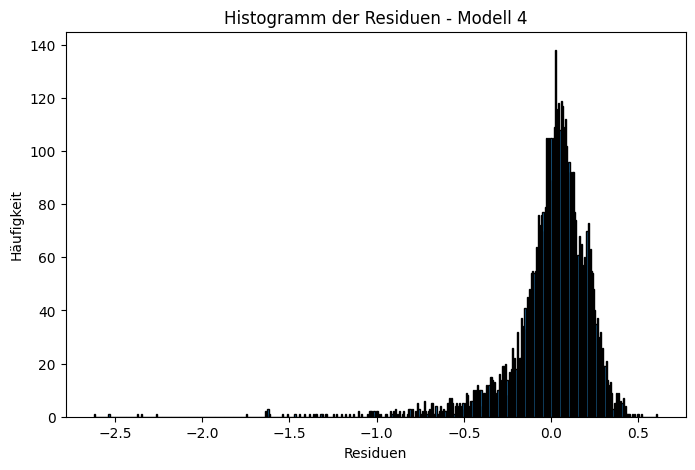

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(residuen_3, bins=500, edgecolor="black")
plt.xlabel("Residuen")
plt.ylabel("Häufigkeit")
plt.title("Histogramm der Residuen - Modell 3")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(residuen_4, bins=500, edgecolor="black")
plt.xlabel("Residuen")
plt.ylabel("Häufigkeit")
plt.title("Histogramm der Residuen - Modell 4")
plt.show()

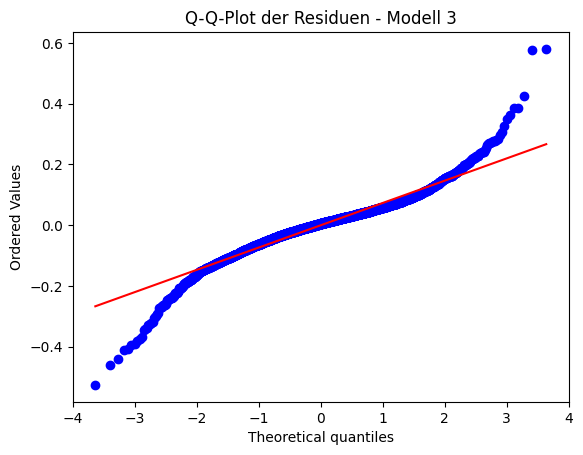

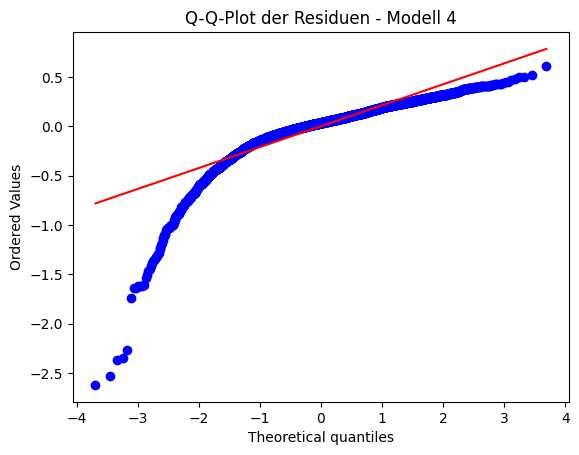

In [30]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(residuen_3, dist="norm", plot=plt)
plt.title("Q-Q-Plot der Residuen - Modell 3")
plt.show()

stats.probplot(residuen_4, dist="norm", plot=plt)
plt.title("Q-Q-Plot der Residuen - Modell 4")
plt.show()